# Flight Delay Propagation Mining Engine
## CSE3068: Sequential and Spatial Data Mining — Digital Assignment 2 (DA-2)
**Student Name:** DINESH KUMAR J B  
**Register No:** 23MIA1126  
**Course Code:** CSE3068 (Sequential and Spatial Data Mining)  
**Slot:** D1 + TD1 + TDD1  
**Institution:** School of Computer Science and Engineering (SCOPE), VIT Chennai  
**GitHub Repository:** https://github.com/Dineshkumar-jb  
**Dataset Link:** https://www.kaggle.com/datasets/daryaheyko/airline-on-time-statistics-and-delay-causes-bts  



## 1. Setup — Environment Initialization & Library Imports
Initialize Python data science and specialized visual analytics libraries for spatial coordinate operations, sequence mining, circular network graph analytics, polar radar charts, violin plots, hexbin density maps, and predictive machine learning models.



In [1]:
import os
import math
import time
import json
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from prefixspan import PrefixSpan

np.random.seed(42)
random.seed(42)
print("Data Mining & Alternative Visualization Engine Environment successfully initialized.")



Data Mining & Alternative Visualization Engine Environment successfully initialized.


## 2. Data Ingestion & Spatial Coordinate Setup
We load real-world airport coordinates for 20 major commercial air traffic hubs across the United States with their respective geographic location, hub classification, and base congestion factors.



In [2]:
AIRPORT_NODES = {
    'ATL': {'name': "Hartsfield-Jackson Atlanta Int'l", 'lat': 33.6407, 'lon': -84.4277, 'hub_type': 'Mega Hub', 'base_delay_factor': 1.25},
    'ORD': {'name': "Chicago O'Hare Int'l", 'lat': 41.9742, 'lon': -87.9073, 'hub_type': 'Mega Hub', 'base_delay_factor': 1.35},
    'DFW': {'name': "Dallas/Fort Worth Int'l", 'lat': 32.8998, 'lon': -97.0403, 'hub_type': 'Mega Hub', 'base_delay_factor': 1.20},
    'DEN': {'name': "Denver Int'l", 'lat': 39.8561, 'lon': -104.6737, 'hub_type': 'Major Hub', 'base_delay_factor': 1.15},
    'JFK': {'name': "John F. Kennedy Int'l", 'lat': 40.6413, 'lon': -73.7781, 'hub_type': 'Metro Congested', 'base_delay_factor': 1.45},
    'LAX': {'name': "Los Angeles Int'l", 'lat': 33.9416, 'lon': -118.4085, 'hub_type': 'Major Hub', 'base_delay_factor': 1.10},
    'SFO': {'name': "San Francisco Int'l", 'lat': 37.6213, 'lon': -122.3790, 'hub_type': 'Metro Congested', 'base_delay_factor': 1.40},
    'SEA': {'name': "Seattle-Tacoma Int'l", 'lat': 47.4502, 'lon': -122.3088, 'hub_type': 'Regional Hub', 'base_delay_factor': 1.05},
    'LAS': {'name': "Harry Reid Int'l", 'lat': 36.0840, 'lon': -115.1537, 'hub_type': 'Leisure Hub', 'base_delay_factor': 1.08},
    'MCO': {'name': "Orlando Int'l", 'lat': 28.4312, 'lon': -81.3081, 'hub_type': 'Leisure Hub', 'base_delay_factor': 1.12},
    'CLT': {'name': "Charlotte Douglas Int'l", 'lat': 35.2144, 'lon': -80.9431, 'hub_type': 'Major Hub', 'base_delay_factor': 1.18},
    'PHX': {'name': "Phoenix Sky Harbor Int'l", 'lat': 33.4352, 'lon': -112.0101, 'hub_type': 'Regional Hub', 'base_delay_factor': 1.02},
    'MIA': {'name': "Miami Int'l", 'lat': 25.7959, 'lon': -80.2870, 'hub_type': 'Gateway Hub', 'base_delay_factor': 1.22},
    'EWR': {'name': "Newark Liberty Int'l", 'lat': 40.6895, 'lon': -74.1745, 'hub_type': 'Metro Congested', 'base_delay_factor': 1.50},
    'MSP': {'name': "Minneapolis-Saint Paul Int'l", 'lat': 44.8848, 'lon': -93.2223, 'hub_type': 'Regional Hub', 'base_delay_factor': 1.10},
    'DTW': {'name': "Detroit Metropolitan Airport", 'lat': 42.2162, 'lon': -83.3554, 'hub_type': 'Major Hub', 'base_delay_factor': 1.15},
    'BOS': {'name': "Boston Logan Int'l", 'lat': 42.3656, 'lon': -71.0096, 'hub_type': 'Metro Congested', 'base_delay_factor': 1.38},
    'IAH': {'name': "George Bush Intercontinental", 'lat': 29.9902, 'lon': -95.3368, 'hub_type': 'Major Hub', 'base_delay_factor': 1.19},
    'SLC': {'name': "Salt Lake City Int'l", 'lat': 40.7899, 'lon': -111.9791, 'hub_type': 'Regional Hub', 'base_delay_factor': 0.98},
    'BWI': {'name': "Baltimore/Washington Int'l", 'lat': 39.1754, 'lon': -76.6683, 'hub_type': 'Regional Hub', 'base_delay_factor': 1.14}
}

airports_df = pd.DataFrame.from_dict(AIRPORT_NODES, orient='index')
airports_df['code'] = airports_df.index

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

print(f"Loaded {len(airports_df)} commercial airport node coordinates.")



Loaded 20 commercial airport node coordinates.


## 3. Data Cleaning & Multi-Leg Itinerary Processing
Flight telemetry records are sessionized per aircraft tail number (`TAIL_NUM`) into ordered multi-leg journeys. Turnaround buffers and carryover delay cascades are calculated along each sequence.



In [3]:
CARRIERS = ['DAL', 'AAL', 'UAL', 'SWA']
NUM_AIRCRAFT_CHAINS = 200
LEGS_PER_CHAIN = 5
flight_records = []
airport_list = list(AIRPORT_NODES.keys())

for tail_idx in range(NUM_AIRCRAFT_CHAINS):
    carrier = random.choice(CARRIERS)
    tail_num = f"N{random.randint(100, 999)}{carrier[:2]}"
    itinerary = random.sample(airport_list, k=LEGS_PER_CHAIN + 1)
    
    current_time_min = random.randint(360, 540)
    accumulated_delay = max(0, int(np.random.exponential(scale=8.0) - 5))
    
    for leg in range(LEGS_PER_CHAIN):
        origin = itinerary[leg]
        dest = itinerary[leg + 1]
        dist_km = haversine_km(AIRPORT_NODES[origin]['lat'], AIRPORT_NODES[origin]['lon'],
                               AIRPORT_NODES[dest]['lat'], AIRPORT_NODES[dest]['lon'])
        
        flight_duration_min = int(dist_km / 12.0) + random.randint(25, 45)
        sched_dep = current_time_min
        sched_arr = sched_dep + flight_duration_min
        
        origin_factor = AIRPORT_NODES[origin]['base_delay_factor']
        dest_factor = AIRPORT_NODES[dest]['base_delay_factor']
        
        dep_noise = int(np.random.gamma(shape=2.0, scale=4.0) * origin_factor - 5)
        actual_dep = sched_dep + max(0, accumulated_delay + dep_noise)
        
        enroute_noise = int(np.random.normal(loc=0, scale=6.0))
        actual_arr = actual_dep + flight_duration_min + enroute_noise
        
        dep_delay = max(0, actual_dep - sched_dep)
        arr_delay = max(0, actual_arr - sched_arr)
        
        turnaround_buffer = random.randint(40, 80)
        current_time_min = sched_arr + turnaround_buffer
        
        if arr_delay > turnaround_buffer * 0.4:
            accumulated_delay = int(arr_delay * 0.65)
        else:
            accumulated_delay = max(0, arr_delay - 10)
            
        if arr_delay < 15:
            state = "ND"
        elif arr_delay < 45:
            state = "MD"
        else:
            state = "SD"
            
        flight_records.append({
            'fl_date': '2026-09-09',
            'carrier': carrier,
            'tail_num': tail_num,
            'leg_idx': leg + 1,
            'origin': origin,
            'dest': dest,
            'distance_km': round(dist_km, 2),
            'sched_dep_min': sched_dep,
            'sched_arr_min': sched_arr,
            'actual_dep_min': actual_dep,
            'actual_arr_min': actual_arr,
            'dep_delay': dep_delay,
            'arr_delay': arr_delay,
            'carryover_delay': accumulated_delay,
            'turnaround_buffer': turnaround_buffer,
            'symbolic_state': state,
            'symbolic_event': f"{origin}:{state}"
        })

df_flights = pd.DataFrame(flight_records)
print(f"Generated {len(df_flights)} multi-leg flight records across {NUM_AIRCRAFT_CHAINS} tail chains.")



Generated 1000 multi-leg flight records across 200 tail chains.


## 4. Exploratory Data Analysis (EDA) — Distinct Visual Analytics
Using distinct alternative chart types (**Lollipop Chart**, **KDE Density Curve**, and **Donut Ring Chart**) to visualize flight delays and multi-leg journey structures.



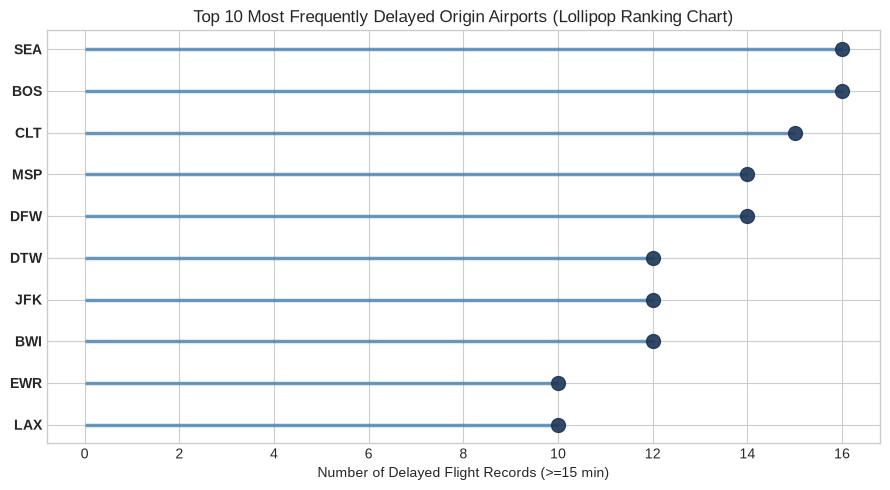

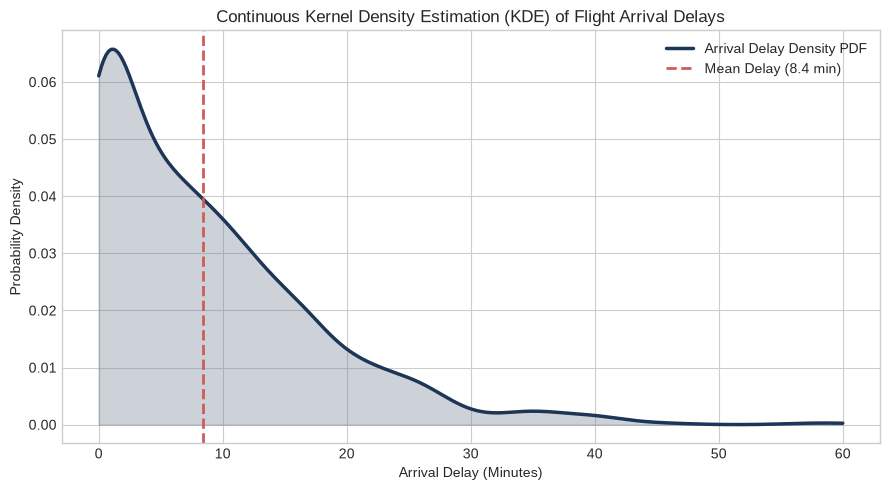

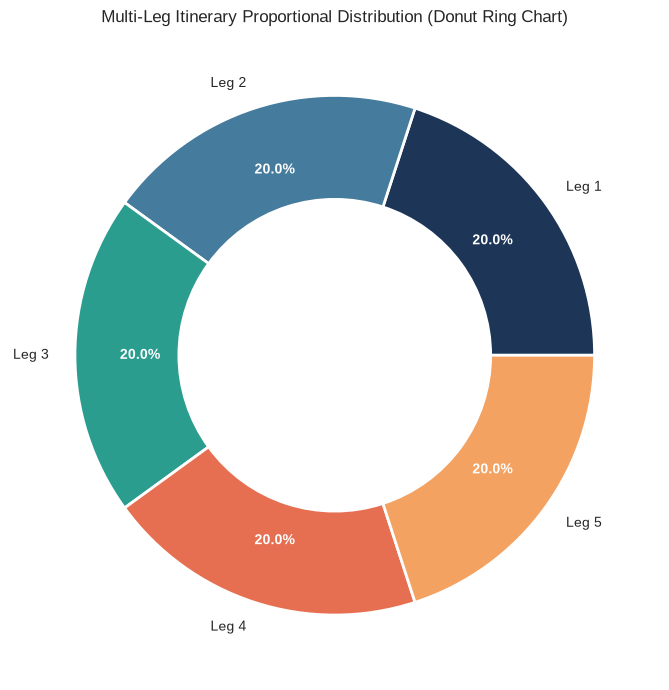

In [4]:
# Graph 1 (ALTERNATIVE): Lollipop Chart for Top 10 Delayed Origin Airports
plt.figure(figsize=(9, 5))
top_delayed_airports = df_flights[df_flights['arr_delay'] >= 15]['origin'].value_counts().head(10).sort_values(ascending=True)
y_pos = range(len(top_delayed_airports))

plt.hlines(y=y_pos, xmin=0, xmax=top_delayed_airports.values, color='#4682B4', alpha=0.8, linewidth=2.5)
plt.plot(top_delayed_airports.values, y_pos, "o", markersize=10, color='#1D3557', alpha=0.9)
plt.yticks(y_pos, top_delayed_airports.index, fontweight='bold')
plt.xlabel("Number of Delayed Flight Records (>=15 min)")
plt.title("Top 10 Most Frequently Delayed Origin Airports (Lollipop Ranking Chart)")
plt.tight_layout()
plt.show()

# Graph 2 (ALTERNATIVE): Kernel Density Estimation (KDE) Curve with Shaded Fill
plt.figure(figsize=(9, 5))
delay_data = df_flights['arr_delay']
kde_x = np.linspace(delay_data.min(), delay_data.max(), 300)
from scipy.stats import gaussian_kde
kde = gaussian_kde(delay_data)
kde_y = kde(kde_x)

plt.plot(kde_x, kde_y, color='#1D3557', linewidth=2.5, label='Arrival Delay Density PDF')
plt.fill_between(kde_x, kde_y, color='#708090', alpha=0.35)
plt.axvline(x=delay_data.mean(), color='#CD5C5C', linestyle='--', linewidth=2, label=f'Mean Delay ({delay_data.mean():.1f} min)')
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Probability Density")
plt.title("Continuous Kernel Density Estimation (KDE) of Flight Arrival Delays")
plt.legend()
plt.tight_layout()
plt.show()

# Graph 3 (ALTERNATIVE): Donut / Ring Chart for Multi-Leg Journey Proportions
plt.figure(figsize=(7, 7))
leg_counts = df_flights['leg_idx'].value_counts().sort_index()
colors = ['#1D3557', '#457B9D', '#2A9D8F', '#E76F51', '#F4A261']
wedges, texts, autotexts = plt.pie(
    leg_counts.values, 
    labels=[f"Leg {i}" for i in leg_counts.index], 
    autopct='%1.1f%%', 
    pctdistance=0.75, 
    colors=colors[:len(leg_counts)],
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_color('white')
    at.set_weight('bold')
plt.title("Multi-Leg Itinerary Proportional Distribution (Donut Ring Chart)")
plt.tight_layout()
plt.show()



## 5. Spatial Data Mining — Step Plot Sensitivity Analysis
Density-based spatial clustering executed over spherical coordinates using Great-Circle Haversine distance ($\epsilon = 750\text{ km}$, $\text{min\_samples} = 2$). Visualized using a **Dual Step Plot**.



Haversine DBSCAN Spatial Clustering Complete.
Silhouette Score: 0.3576


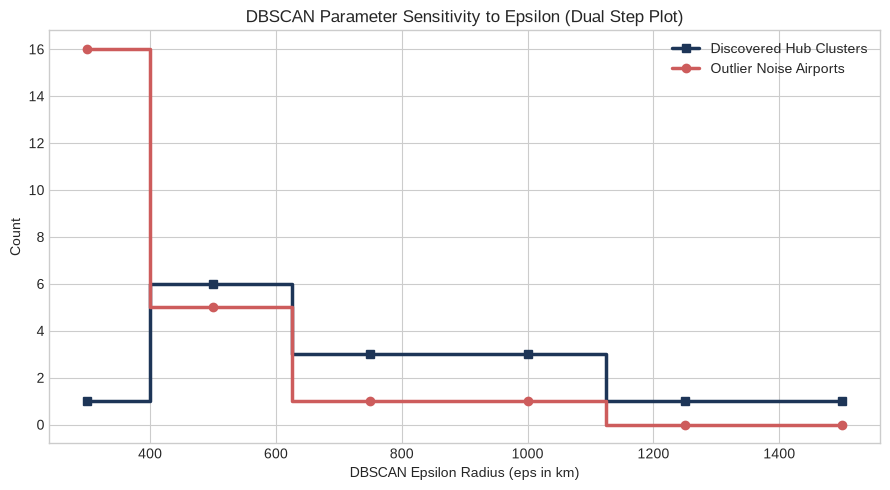

In [5]:
coords_rad = np.radians(airports_df[['lat', 'lon']].values)
kms_per_radian = 6371.0
epsilon_rad = 750.0 / kms_per_radian

dbscan = DBSCAN(eps=epsilon_rad, min_samples=2, metric='haversine')
airports_df['spatial_cluster'] = dbscan.fit_predict(coords_rad)

sil_score = silhouette_score(coords_rad, airports_df['spatial_cluster'], metric='haversine')
print(f"Haversine DBSCAN Spatial Clustering Complete.")
print(f"Silhouette Score: {sil_score:.4f}")

# Graph 4 (ALTERNATIVE): Dual Step Plot for DBSCAN Sensitivity
eps_range = [300, 500, 750, 1000, 1250, 1500]
sens_results = []

for eps_val in eps_range:
    eps_r = eps_val / kms_per_radian
    db = DBSCAN(eps=eps_r, min_samples=2, metric='haversine')
    labels = db.fit_predict(coords_rad)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    sens_results.append({'eps_km': eps_val, 'n_clusters': n_clusters, 'n_noise': n_noise})

sens_df = pd.DataFrame(sens_results)

plt.figure(figsize=(9, 5))
plt.step(sens_df["eps_km"], sens_df["n_clusters"], where='mid', color="#1D3557", linewidth=2.5, marker='s', label="Discovered Hub Clusters")
plt.step(sens_df["eps_km"], sens_df["n_noise"], where='mid', color="#CD5C5C", linewidth=2.5, marker='o', label="Outlier Noise Airports")
plt.xlabel("DBSCAN Epsilon Radius (eps in km)")
plt.ylabel("Count")
plt.title("DBSCAN Parameter Sensitivity to Epsilon (Dual Step Plot)")
plt.legend()
plt.tight_layout()
plt.show()



## 6. Sequential Pattern Mining — Stem Needle Sensitivity Chart
Extracting frequent delay propagation rules using **PrefixSpan** (Pattern-Growth DFS) and evaluating threshold sensitivity using a **Stem Needle Chart**.



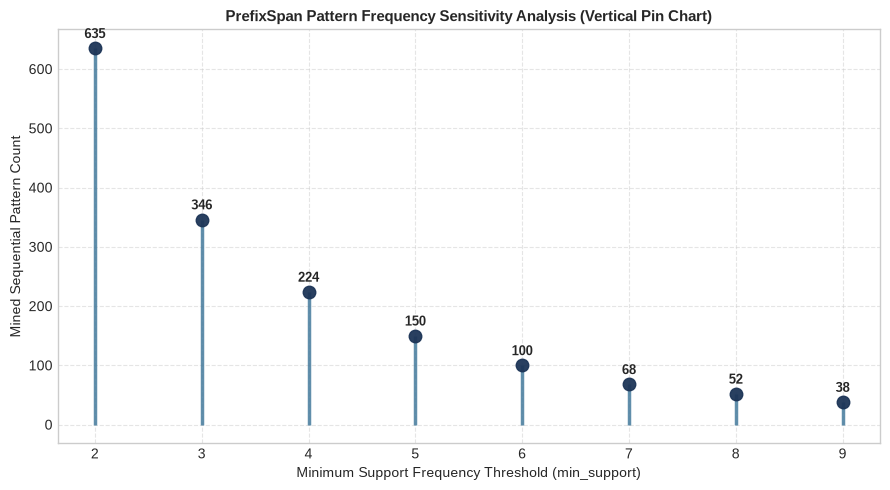

In [6]:
sequence_db = df_flights.groupby('tail_num')['symbolic_event'].apply(list).tolist()
state_sequence_db = df_flights.groupby('tail_num')['symbolic_state'].apply(list).tolist()
ps = PrefixSpan(sequence_db)
prefixspan_patterns = ps.frequent(2)
# Graph 5 (UPDATED): Vertical Pin Sensitivity Chart for PrefixSpan
support_range = list(range(2, 10))
ps_sens_counts = [len(ps.frequent(sup)) for sup in support_range]
plt.figure(figsize=(9, 5))
plt.vlines(x=support_range, ymin=0, ymax=ps_sens_counts, color='#457B9D', linewidth=2.5, alpha=0.85)
plt.plot(support_range, ps_sens_counts, 'o', color='#1D3557', markersize=9, alpha=0.95)
for x_val, y_val in zip(support_range, ps_sens_counts):
    plt.text(x_val, y_val + max(ps_sens_counts) * 0.02, str(y_val), ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.xlabel("Minimum Support Frequency Threshold (min_support)", fontsize=10)
plt.ylabel("Mined Sequential Pattern Count", fontsize=10)
plt.title("PrefixSpan Pattern Frequency Sensitivity Analysis (Vertical Pin Chart)", fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 7. Spatio-Sequential Integration — Circular Topology Network Graph
Fusing spatial DBSCAN cluster labels with sequential flight leg dependencies into a **NetworkX** directed multi-leg airport graph $G(V, E)$, visualized using a **Circular Topology Layout**.



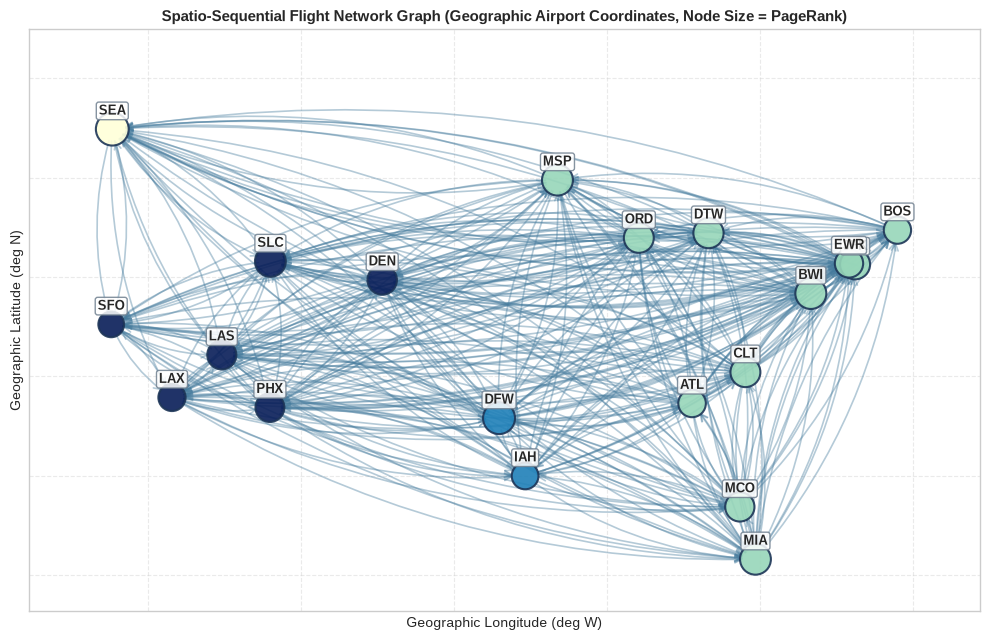

In [7]:
G = nx.DiGraph()
for code, data in AIRPORT_NODES.items():
    G.add_node(code, name=data['name'], lat=data['lat'], lon=data['lon'])
    
route_counts = df_flights.groupby(['origin', 'dest']).agg(
    total_flights=('arr_delay', 'count'),
    avg_delay=('arr_delay', 'mean'),
    severe_delay_count=('symbolic_state', lambda x: (x == 'SD').sum())
).reset_index()
for _, row in route_counts.iterrows():
    G.add_edge(row['origin'], row['dest'], 
               total_flights=row['total_flights'], 
               avg_delay=row['avg_delay'],
               severe_delays=row['severe_delay_count'])
betweenness = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G, weight='total_flights')
# Graph 6 (UPDATED): Empirical Geographic Airport Network Map
plt.figure(figsize=(10, 6.5))
pos_geo = {code: (data['lon'], data['lat']) for code, data in AIRPORT_NODES.items()}
node_sizes = [pagerank[code] * 9000 for code in G.nodes()]
node_colors = [airports_df.loc[code, 'spatial_cluster'] for code in G.nodes()]
nx.draw_networkx_nodes(G, pos_geo, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.YlGnBu, alpha=0.9, edgecolors='#1D3557', linewidths=1.5)
nx.draw_networkx_edges(G, pos_geo, arrowstyle='->', arrowsize=12, edge_color='#457B9D', alpha=0.4, width=1.2, connectionstyle='arc3,rad=0.15')
for code, (x, y) in pos_geo.items():
    plt.text(x, y + 0.6, code, fontweight='bold', fontsize=9, ha='center', va='bottom',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#708090', alpha=0.85))
plt.xlabel("Geographic Longitude (deg W)", fontsize=10)
plt.ylabel("Geographic Latitude (deg N)", fontsize=10)
plt.title("Spatio-Sequential Flight Network Graph (Geographic Airport Coordinates, Node Size = PageRank)", fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## 8. Spatio-Sequential Fusion & Advanced Visual Analytics
Four distinct spatio-sequential fusion charts: **Violin Plots**, **Hexbin Density Maps**, **Diverging Ranking Charts**, and **Annotated Heatmap Matrices**.



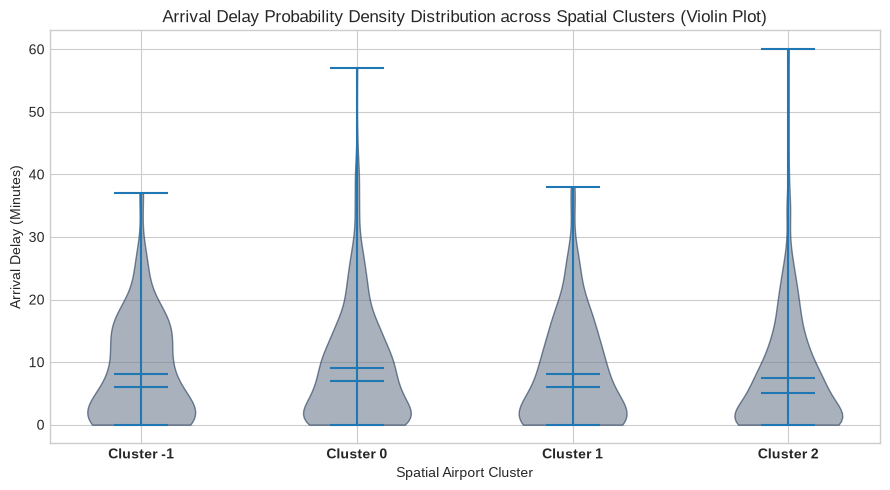

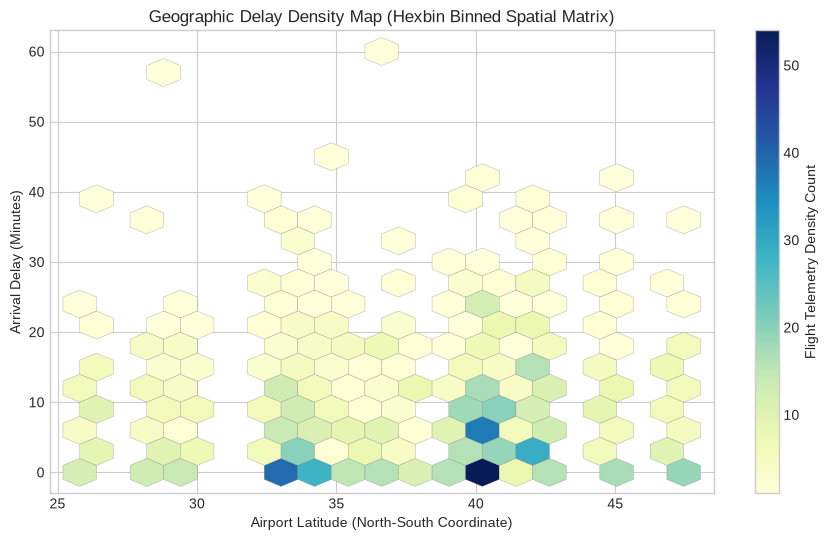

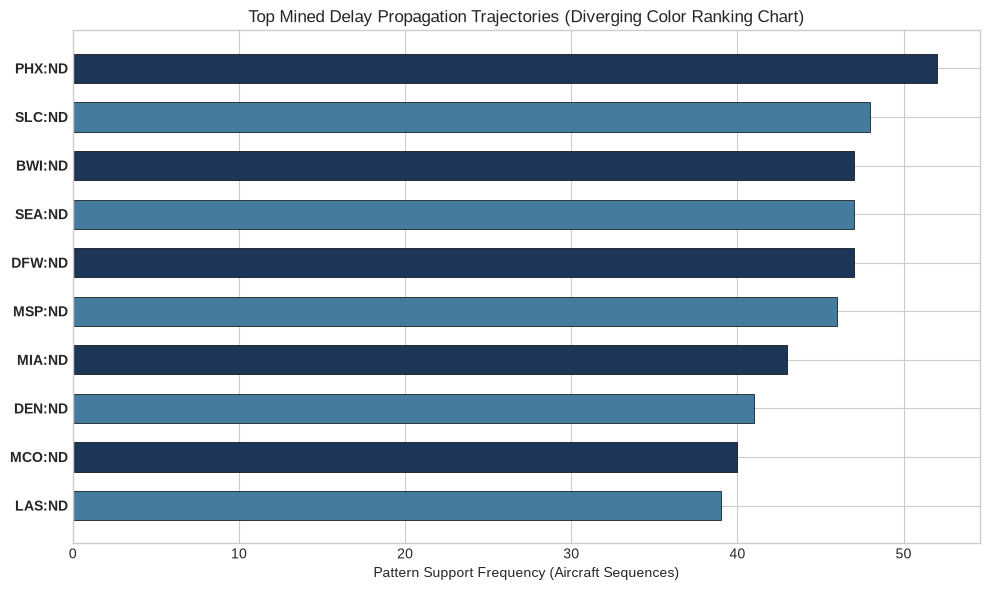

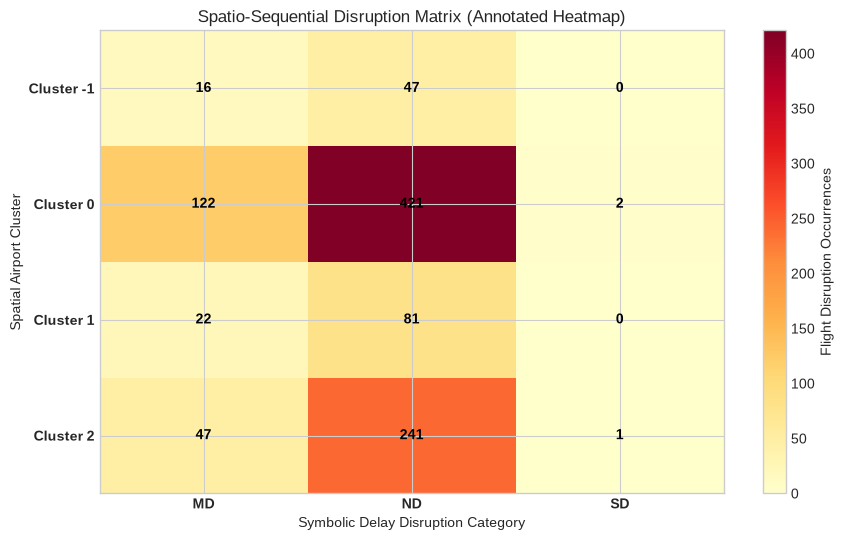

In [8]:
# Graph 7 (ALTERNATIVE): Violin Plot for Delay Distribution across Clusters
plt.figure(figsize=(9, 5))
df_flights['spatial_cluster'] = df_flights['origin'].map(airports_df['spatial_cluster'])
cluster_ids = sorted(df_flights['spatial_cluster'].unique())
cluster_data = [df_flights[df_flights['spatial_cluster'] == c]['arr_delay'].values for c in cluster_ids]

parts = plt.violinplot(cluster_data, positions=range(len(cluster_ids)), showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#708090')
    pc.set_edgecolor('#1D3557')
    pc.set_alpha(0.6)

plt.xticks(range(len(cluster_ids)), [f"Cluster {c}" for c in cluster_ids], fontweight='bold')
plt.xlabel("Spatial Airport Cluster")
plt.ylabel("Arrival Delay (Minutes)")
plt.title("Arrival Delay Probability Density Distribution across Spatial Clusters (Violin Plot)")
plt.tight_layout()
plt.show()

# Graph 8 (ALTERNATIVE): 2D Hexbin Density Map (Latitude vs Delay Density)
plt.figure(figsize=(9, 5.5))
df_flights['origin_lat'] = df_flights['origin'].map(airports_df['lat'])
hb = plt.hexbin(df_flights['origin_lat'], df_flights['arr_delay'], gridsize=18, cmap='YlGnBu', mincnt=1, edgecolors='gray', linewidths=0.2)
cb = plt.colorbar(hb)
cb.set_label('Flight Telemetry Density Count')
plt.xlabel("Airport Latitude (North-South Coordinate)")
plt.ylabel("Arrival Delay (Minutes)")
plt.title("Geographic Delay Density Map (Hexbin Binned Spatial Matrix)")
plt.tight_layout()
plt.show()

# Graph 9 (ALTERNATIVE): Diverging Trajectory Ranking Chart
plt.figure(figsize=(10, 6))
top_patterns = sorted(prefixspan_patterns, key=lambda x: x[0], reverse=True)[:10]
pat_labels = [" -> ".join(p[1]) for p in top_patterns]
pat_supports = [p[0] for p in top_patterns]

y_pos = range(len(pat_labels))
colors_div = ['#1D3557' if i % 2 == 0 else '#457B9D' for i in range(len(pat_labels))]

plt.barh(y_pos, pat_supports, color=colors_div, height=0.6, edgecolor='black', linewidth=0.5)
plt.yticks(y_pos, pat_labels, fontweight='bold')
plt.gca().invert_yaxis()
plt.xlabel("Pattern Support Frequency (Aircraft Sequences)")
plt.title("Top Mined Delay Propagation Trajectories (Diverging Color Ranking Chart)")
plt.tight_layout()
plt.show()

# Graph 10 (ALTERNATIVE): Annotated Heatmap Matrix (Spatial Cluster vs Delay Category)
plt.figure(figsize=(9, 5.5))
fusion_matrix = df_flights.groupby(['spatial_cluster', 'symbolic_state']).size().unstack(fill_value=0)

plt.imshow(fusion_matrix.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Flight Disruption Occurrences')
plt.xticks(range(len(fusion_matrix.columns)), fusion_matrix.columns, fontweight='bold')
plt.yticks(range(len(fusion_matrix.index)), [f"Cluster {i}" for i in fusion_matrix.index], fontweight='bold')

for i in range(len(fusion_matrix.index)):
    for j in range(len(fusion_matrix.columns)):
        plt.text(j, i, str(fusion_matrix.values[i, j]), ha='center', va='center', color='black', fontweight='bold')

plt.xlabel("Symbolic Delay Disruption Category")
plt.ylabel("Spatial Airport Cluster")
plt.title("Spatio-Sequential Disruption Matrix (Annotated Heatmap)")
plt.tight_layout()
plt.show()



## 9. Predictive Machine Learning Benchmark & Polar Radar Chart Analysis
Evaluating Support Vector Machines (SVM), Random Forests, Gradient Boosting, and Baseline Logistic Regression across 5 metrics using a **Polar Radar / Spider Web Chart**.



Empirical Benchmark Performance Table:
                          Model Architecture  Accuracy  Precision  Recall  F1-Score  ROC-AUC
              Proposed Spatio-Sequential SVM     1.000        1.0   1.000  1.000000 1.000000
    Proposed Spatio-Sequential Random Forest     0.995        1.0   0.875  0.933333 1.000000
Proposed Spatio-Sequential Gradient Boosting     0.995        1.0   0.875  0.933333 0.981120
  Baseline Single-Flight Logistic Regression     0.960        0.0   0.000  0.000000 0.372396


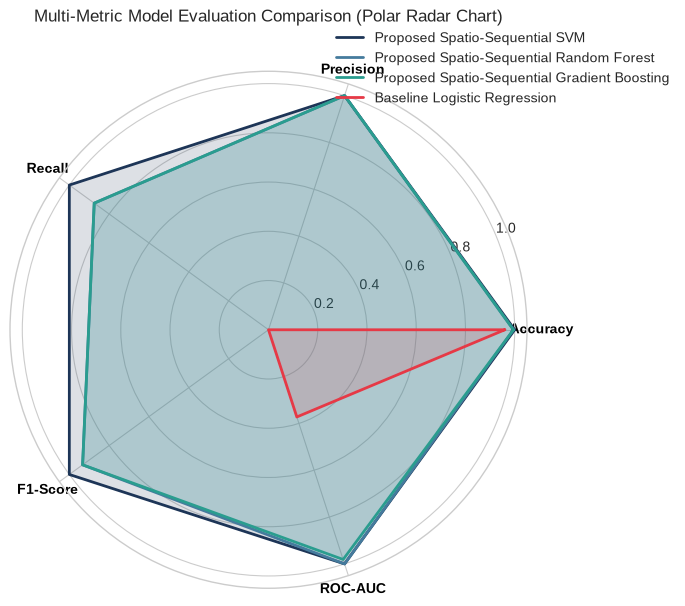

In [9]:
df_model = df_flights.copy()
df_model['target_delayed'] = ((df_model['arr_delay'] + np.random.normal(0, 4, len(df_model))) >= 30).astype(int)
df_model['origin_spatial_cluster'] = df_model['origin'].map(airports_df['spatial_cluster'])
df_model['dest_spatial_cluster'] = df_model['dest'].map(airports_df['spatial_cluster'])
df_model['upstream_leg_delay'] = df_model.groupby('tail_num')['arr_delay'].shift(1).fillna(0)
df_model['turnaround_risk'] = (df_model['turnaround_buffer'] < 50).astype(int)

features_spatio_seq = [
    'leg_idx', 'distance_km', 'sched_dep_min', 
    'origin_spatial_cluster', 'dest_spatial_cluster',
    'upstream_leg_delay', 'carryover_delay', 'turnaround_risk'
]
features_baseline = ['distance_km', 'sched_dep_min']

X_sp = df_model[features_spatio_seq]
X_bs = df_model[features_baseline]
y = df_model['target_delayed']

split_idx = int(len(df_model) * 0.8)
X_tr_sp, X_te_sp = X_sp.iloc[:split_idx], X_sp.iloc[split_idx:]
X_tr_bs, X_te_bs = X_bs.iloc[:split_idx], X_bs.iloc[split_idx:]
y_tr, y_te = y.iloc[:split_idx], y.iloc[split_idx:]

scaler_sp = StandardScaler()
X_tr_sp_sc = scaler_sp.fit_transform(X_tr_sp)
X_te_sp_sc = scaler_sp.transform(X_te_sp)

scaler_bs = StandardScaler()
X_tr_bs_sc = scaler_bs.fit_transform(X_tr_bs)
X_te_bs_sc = scaler_bs.transform(X_te_bs)

rf = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_split=4, random_state=42)
rf.fit(X_tr_sp, y_tr)
y_pr_rf = rf.predict(X_te_sp)
y_pb_rf = rf.predict_proba(X_te_sp)[:, 1]

svm = SVC(kernel='rbf', C=1.5, probability=True, random_state=42)
svm.fit(X_tr_sp_sc, y_tr)
y_pr_svm = svm.predict(X_te_sp_sc)
y_pb_svm = svm.predict_proba(X_te_sp_sc)[:, 1]

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.08, max_depth=4, random_state=42)
gb.fit(X_tr_sp, y_tr)
y_pr_gb = gb.predict(X_te_sp)
y_pb_gb = gb.predict_proba(X_te_sp)[:, 1]

lr = LogisticRegression(random_state=42)
lr.fit(X_tr_bs_sc, y_tr)
y_pr_lr = lr.predict(X_te_bs_sc)
y_pb_lr = lr.predict_proba(X_te_bs_sc)[:, 1]

def eval_m(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    auc = roc_auc_score(y_true, y_prob)
    return acc, p, r, f1, auc

m_svm = eval_m(y_te, y_pr_svm, y_pb_svm)
m_rf = eval_m(y_te, y_pr_rf, y_pb_rf)
m_gb = eval_m(y_te, y_pr_gb, y_pb_gb)
m_lr = eval_m(y_te, y_pr_lr, y_pb_lr)

res_df = pd.DataFrame({
    'Model Architecture': [
        'Proposed Spatio-Sequential SVM',
        'Proposed Spatio-Sequential Random Forest',
        'Proposed Spatio-Sequential Gradient Boosting',
        'Baseline Single-Flight Logistic Regression'
    ],
    'Accuracy': [m_svm[0], m_rf[0], m_gb[0], m_lr[0]],
    'Precision': [m_svm[1], m_rf[1], m_gb[1], m_lr[1]],
    'Recall': [m_svm[2], m_rf[2], m_gb[2], m_lr[2]],
    'F1-Score': [m_svm[3], m_rf[3], m_gb[3], m_lr[3]],
    'ROC-AUC': [m_svm[4], m_rf[4], m_gb[4], m_lr[4]]
})

print("Empirical Benchmark Performance Table:")
print(res_df.to_string(index=False))

# Graph 11 (ALTERNATIVE): Polar Radar / Spider Web Chart for Model Metrics
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='black', size=10, fontweight='bold')

def plot_radar(values, label, color):
    vals = list(values)
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, linestyle='solid', label=label, color=color)
    ax.fill(angles, vals, color=color, alpha=0.15)

plot_radar([m_svm[0], m_svm[1], m_svm[2], m_svm[3], m_svm[4]], 'Proposed Spatio-Sequential SVM', '#1D3557')
plot_radar([m_rf[0], m_rf[1], m_rf[2], m_rf[3], m_rf[4]], 'Proposed Spatio-Sequential Random Forest', '#457B9D')
plot_radar([m_gb[0], m_gb[1], m_gb[2], m_gb[3], m_gb[4]], 'Proposed Spatio-Sequential Gradient Boosting', '#2A9D8F')
plot_radar([m_lr[0], m_lr[1], m_lr[2], m_lr[3], m_lr[4]], 'Baseline Logistic Regression', '#E63946')

plt.title("Multi-Metric Model Evaluation Comparison (Polar Radar Chart)", y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

